⚠️ This project is mandatory for certification bloc #2.

![Tinder](https://full-stack-assets.s3.eu-west-3.amazonaws.com/M03-EDA/Tinder-Symbole.png)

# Speed Dating with Tinder

what makes people interested into each other.

 Ils devaient également évaluer leur rendez-vous selon six critères : 
 - attractivité 
 - sincérité 
 - intelligence,
 - sens de l'humour
 - ambition 
 - intérêts communs

Plusieurs questionnaires à différents moments: Speed Dating Data Key
- données démographiues
- habitude en matière de rencontres 
- perception de soi selon différents critére clés 
- les croyance sur ce ue les autres rechercehnt chez un partenaire 
- mode vie 

Quels sont les attributs les moins recherchés chez un partenaire masculin ?         
Est-ce différent pour les partenaires féminines ?       
Quelle importance les gens accordent-ils à l'attrait physique dans le choix d'un partenaire potentiel par rapport à son impact réel ?       
Les intérêts communs sont-ils plus importants que l'origine ethnique commune ?      
Les gens peuvent-ils prédire avec précision leur propre valeur perçue sur le marché des rencontres ?        
Pour obtenir un deuxième rendez-vous, vaut-il mieux être le premier ou le dernier rendez-vous rapide de la soirée ?         


In [14]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
import math

In [15]:
df = pd.read_csv('Speed+Dating+Data.csv', encoding='latin-1')
# Le fichier n'est pas en UTF-8, il est donc convertit en latin-1 

In [16]:
df.columns.tolist()

['iid',
 'id',
 'gender',
 'idg',
 'condtn',
 'wave',
 'round',
 'position',
 'positin1',
 'order',
 'partner',
 'pid',
 'match',
 'int_corr',
 'samerace',
 'age_o',
 'race_o',
 'pf_o_att',
 'pf_o_sin',
 'pf_o_int',
 'pf_o_fun',
 'pf_o_amb',
 'pf_o_sha',
 'dec_o',
 'attr_o',
 'sinc_o',
 'intel_o',
 'fun_o',
 'amb_o',
 'shar_o',
 'like_o',
 'prob_o',
 'met_o',
 'age',
 'field',
 'field_cd',
 'undergra',
 'mn_sat',
 'tuition',
 'race',
 'imprace',
 'imprelig',
 'from',
 'zipcode',
 'income',
 'goal',
 'date',
 'go_out',
 'career',
 'career_c',
 'sports',
 'tvsports',
 'exercise',
 'dining',
 'museums',
 'art',
 'hiking',
 'gaming',
 'clubbing',
 'reading',
 'tv',
 'theater',
 'movies',
 'concerts',
 'music',
 'shopping',
 'yoga',
 'exphappy',
 'expnum',
 'attr1_1',
 'sinc1_1',
 'intel1_1',
 'fun1_1',
 'amb1_1',
 'shar1_1',
 'attr4_1',
 'sinc4_1',
 'intel4_1',
 'fun4_1',
 'amb4_1',
 'shar4_1',
 'attr2_1',
 'sinc2_1',
 'intel2_1',
 'fun2_1',
 'amb2_1',
 'shar2_1',
 'attr3_1',
 'sinc3_1',
 

In [17]:
df.head(10)

,iid,id,gender,idg,condtn,wave,round,position,positin1,order,...,attr3_3,sinc3_3,intel3_3,fun3_3,amb3_3,attr5_3,sinc5_3,intel5_3,fun5_3,amb5_3
0,1,1.0,0,1,1,1,10,7,NaN,4,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
1,1,1.0,0,1,1,1,10,7,NaN,3,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
2,1,1.0,0,1,1,1,10,7,NaN,10,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
3,1,1.0,0,1,1,1,10,7,NaN,5,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
4,1,1.0,0,1,1,1,10,7,NaN,7,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
5,1,1.0,0,1,1,1,10,7,NaN,6,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
6,1,1.0,0,1,1,1,10,7,NaN,1,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
7,1,1.0,0,1,1,1,10,7,NaN,2,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
8,1,1.0,0,1,1,1,10,7,NaN,8,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
9,1,1.0,0,1,1,1,10,7,NaN,9,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN


In [18]:
display(df.shape)

(8378, 195)

# Isolation 

First, we group related columns together to make them easier to handle

- **background variables**: regarding the identification of participants, their interests, and their demographic data 
- **feedback variables** : Regarding their feedback on dates and matches 
-  **Time-dependent responses** : their answers for each question, sorted by time 

In [19]:
# --- Isolation of background variables ---
# Identifiers: 
identifiers = ['iid', 'id', 'idg', 'gender', 'wave', 'round', 'position', 'positin1', 'order', 'condtn']

# partner information: 
partner = ['age_o', 'race_o', 'samerace', 'int_corr']

# scorecard : Filled out by subjects after each "date" during the event
scorecard = ['attr', 'sinc', 'intel', 'fun', 'amb', 'shar', 'like', 'prob', 'met']
scorecard_partner = ['attr_o', 'sinc_o', 'intel_o', 'fun_o', 'amb_o', 'shar_o', 'like_o', 'prob_o', 'met_o']
preferences_partner = ['pf_o_att', 'pf_o_sin', 'pf_o_int', 'pf_o_fun', 'pf_o_amb', 'pf_o_sha']

# Demographic and social information: 
demographics = ['age','field_cd', 'race', 'imprace', 'imprelig', 'from', 'zipcode']
social_level = ['from', 'mn_sat', 'field', 'field_cd', 'career', 'career_c', 'undergrd' ]
standard_living = ['income', 'zipcode', 'tuition']

# goal and habits: 
goal_habits = ['goal', 'date', 'go_out', 'exphappy', 'expnum']

# activities: 
activities = ['sports', 'tvsports', 'exercise', 'dining', 'museums', 'art','hiking', 'gaming', 'clubbing', 'reading', 'tv', 'theater','movies', 'concerts', 'music', 'shopping', 'yoga']


# --- Isolation of feed-back variables ---
# match variables 
match_during_event = ['partner', 'pid', 'match', 'dec', 'dec_o', 'match_es']

# Satisfaction post-event: 
satisfaction_post_event = ['satis_2', 'length', 'numdat_2']

# match tracking after 4 weeks 
match_follow_up = ['you_call', 'them_cal', 'date_3', 'numdat_3', 'num_in_3']

In [20]:
# --- Isolation of responses for each question for each time --- 
# question documentation
QUESTIONS = {
    'q1' : 'What are you looking for in the opposite sex?',
    'q2' : 'What do you think the opposite sex looks for in a date?',
    'q3' : 'How do you think you measure up?',
    'q4' : 'What do you think MOST of your fellow men/women look for in the opposite sex?',
    'q5' : 'How do you think others perceive you?',
    'q6' : 'How important were these attributes during the date?'
}

# TIME 01 : Sign-up Survey = 
time_01 = {
    'q1' : ['attr1_1','sinc1_1','intel1_1','fun1_1','amb1_1','shar1_1'],
    'q2' : ['attr2_1','sinc2_1','intel2_1','fun2_1','amb2_1','shar2_1'],
    'q3' : ['attr3_1','sinc3_1','fun3_1','intel3_1','amb3_1',],
    'q4' : ['attr4_1','sinc4_1','intel4_1','fun4_1','amb4_1','shar4_1'],
    'q5' : ['attr5_1','sinc5_1','intel5_1','fun5_1','amb5_1'],
}

# TIME 01_bis : Half way through meeting
time_halfway = {
    'q1' : ['attr1_s', 'sinc1_s', 'intel1_s', 'fun1_s', 'amb1_s', 'shar1_s'],
    'q3' : ['attr3_s', 'sinc3_s', 'intel3_s', 'fun3_s', 'amb3_s']
}

# TIME 02 : the next day
time_02 = {    
    'q1' : ['attr1_2','sinc1_2','intel1_2','fun1_2','amb1_2','shar1_2'],
    'q2' : ['attr2_2','sinc2_2','intel2_2','fun2_2','amb2_2','shar2_2'],
    'q3' : ['attr3_2','sinc3_2','fun3_2','intel3_2','amb3_2',],
    'q4' : ['attr4_2','sinc4_2','intel4_2','fun4_2','amb4_2','shar4_2'],
    'q5' : ['attr5_2','sinc5_2','intel5_2','fun5_2','amb5_2'],
    'q6' : ['attr7_2','sinc7_2','intel7_2','fun7_2','amb7_2','shar7_2']
}

# TIME 03 : 3 or 4 weeks later
time_03 = {    
    'q1' : ['attr1_3','sinc1_3','intel1_3','fun1_3','amb1_3','shar1_3'],
    'q2' : ['attr2_3','sinc2_3','intel2_3','fun2_3','amb2_3','shar2_3'],
    'q3' : ['attr3_3','sinc3_3','fun3_3','intel3_3','amb3_3',],
    'q4' : ['attr4_3','sinc4_3','intel4_3','fun4_3','amb4_3','shar4_3'],
    'q5' : ['attr5_3','sinc5_3','intel5_3','fun5_3','amb5_3'],
    'q6' : ['attr7_3','sinc7_3','intel7_3','fun7_3','amb7_3','shar7_3']
}

# Master dictionary grouping all time periods
ALL_RESPONSES = {
    'time_01' : time_01,
    'time_halfway' : time_halfway,
    'time_02' : time_02,
    'time_03' : time_03
}

# Mask creation 
creation of masks to facilitate main selections 

In [21]:
# Gender 
female = df['gender'] == 0 
male = df['gender'] == 1 

# Matchs 
matchs_yes = df['match'] == 1 
matchs_no = df['match'] == 0
matchs_real = df['date_3'] == 1 
matchs_real_number = (df['numdat_3'] == 1) & (df['num_in_3'])
matchs_call = (df['you_call'] > 0) | (df['them_cal'] > 0)
partner_yes = df['dec_o'] == 1 
rejected = (df['dec'] == 1) & (df['dec_o'] == 0)
rejector = (df['dec'] == 0) & (df['dec_o'] == 1)

# Age 
young = df['age'] < 27
middle_age = (df['age'] >= 27) & (df['age'] < 35)
adult= (df['age'] >= 35) & (df['age'] < 42)
older = (df['age'] >= 42)

# Career 
art = df['career'].isin([6, 17])
literary = df['career'].isin([1, 13, 16])
social = df['career'].isin([3, 4, 11, 12, 9])
business = df['career'].isin([7, 8])
science = df['career'][5]
sport = df['career'][14]
university = df['career'][2]
other = df['career'].isin([10, 15])

# Goal 
goal_fun = df['goal'] == 1 
goal_meet = df['goal'] == 2
goal_date = df['goal'] == 3
goal_serious = df['goal'] == 4
goal_action = df['goal'] == 5
goal_other = df['goal'] == 6     

# dating habits
date_often = df['date'].isin([1, 2, 3])
date_rarely = df['date'].isin([1, 2, 3])

# condition of experiment 
limited_choice = df['condtn'] == 1 
extensive_choice = df['condtn'] == 2 

# satisfaction 
satisfied = df['satis_2'] >= 5 
unsatisfied = df['satis_2'] < 5 

In [22]:
display(df['age'].max())

55.0

# Normalization 

Groups 6 to 9 have different scorecards; they had to score from 1 to 10 rather than with a limited number of 100 points like the other groups.

After observing whether there is a noticeable difference between the scorecards, we will normalize the data. 

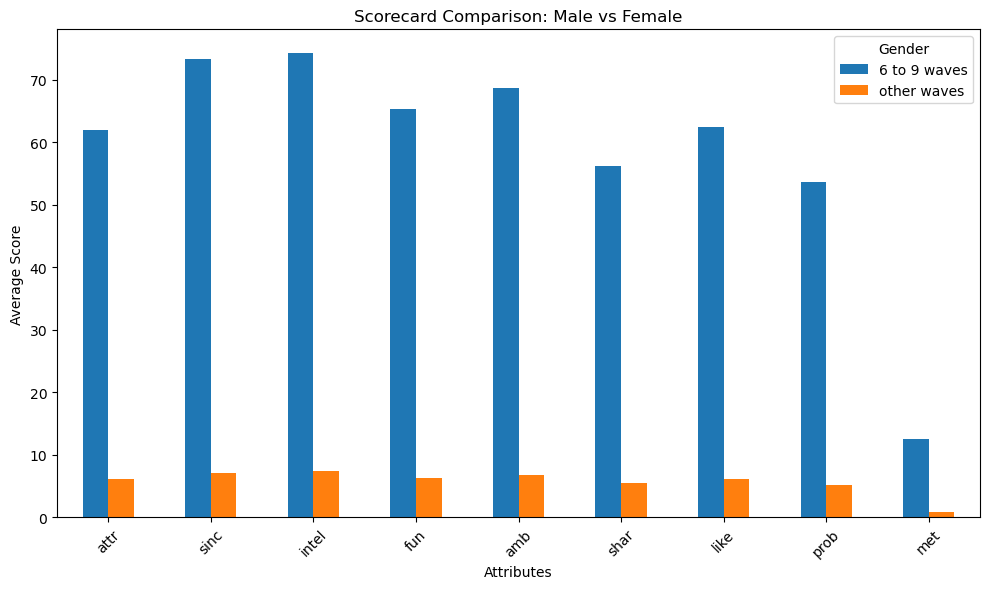

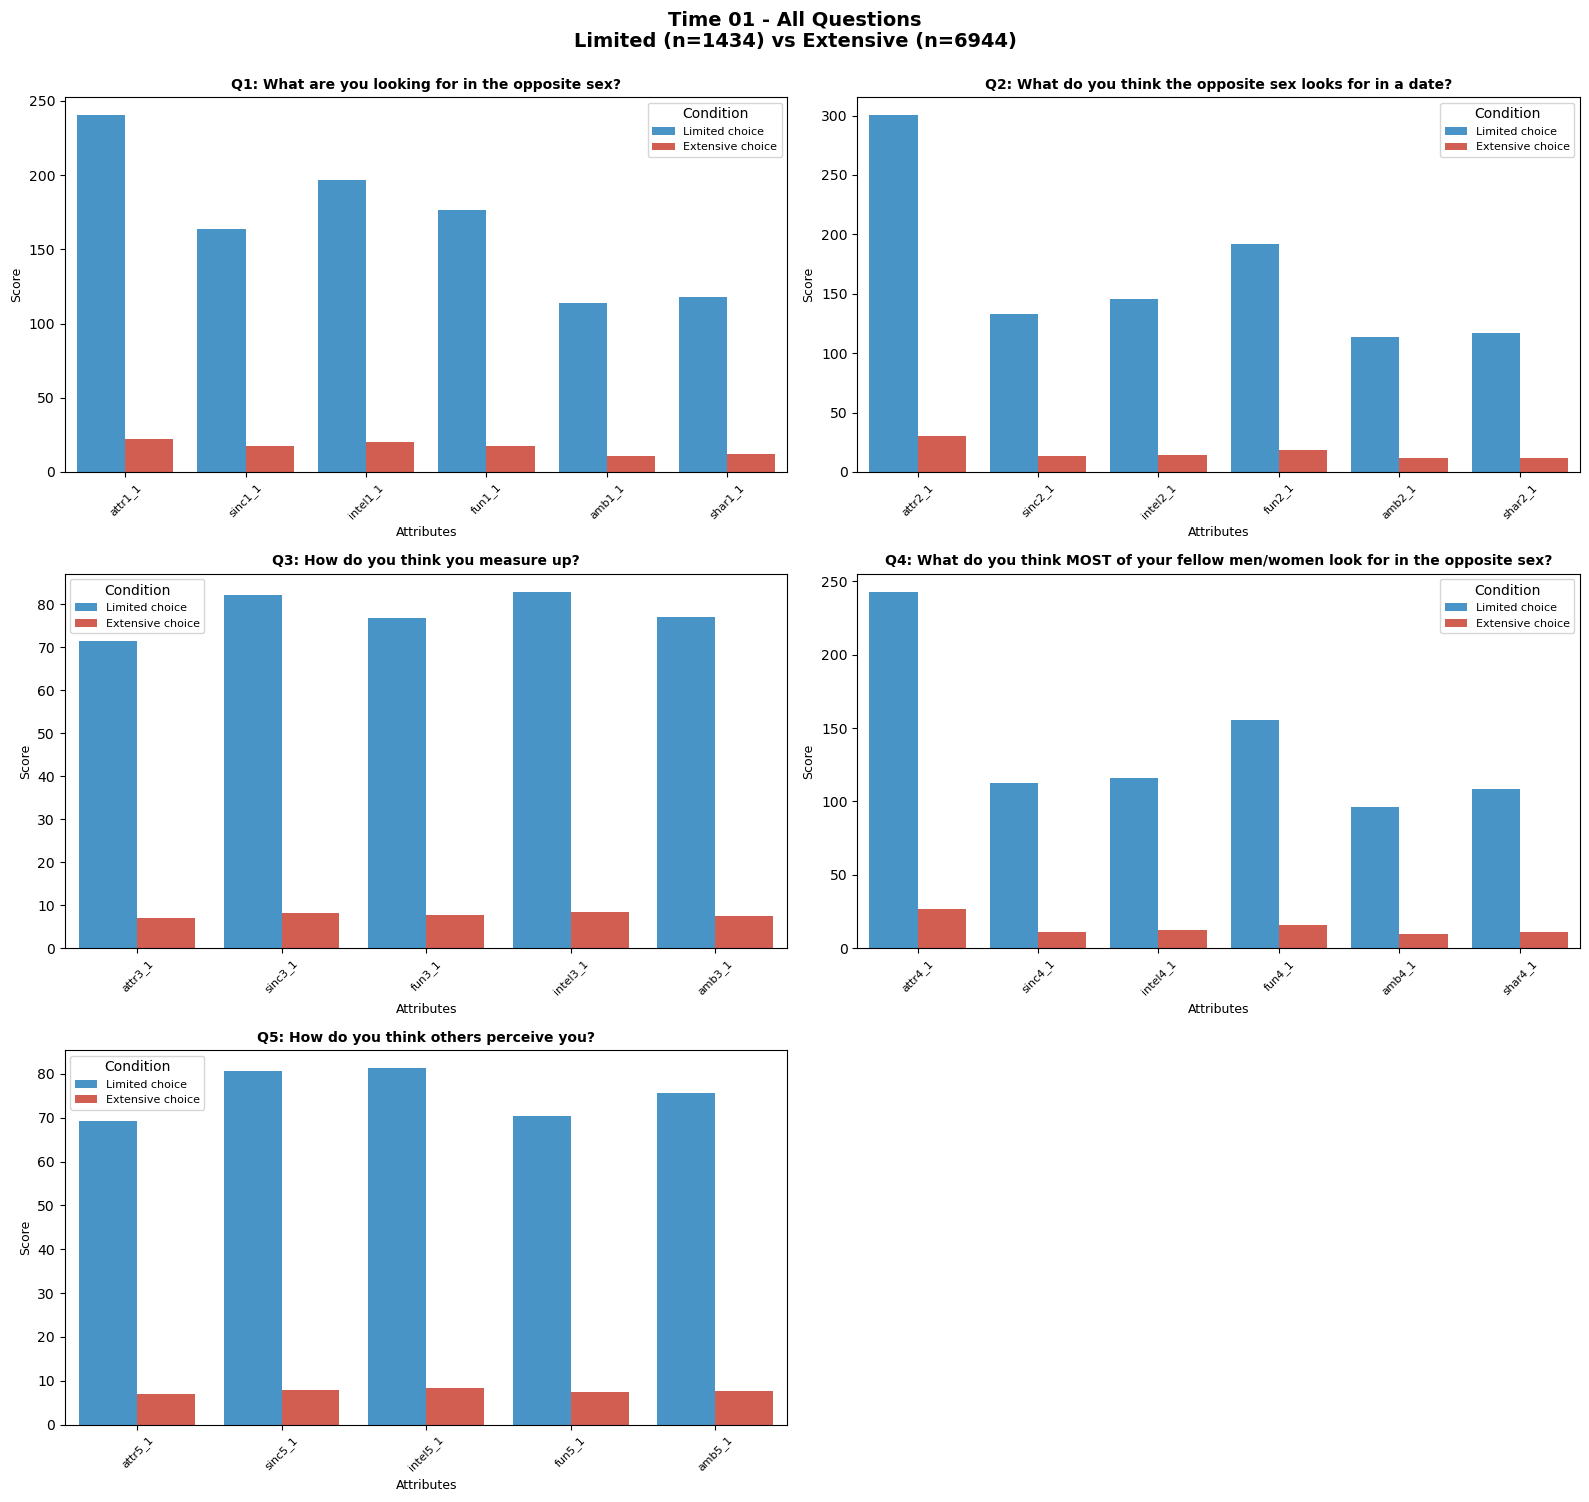

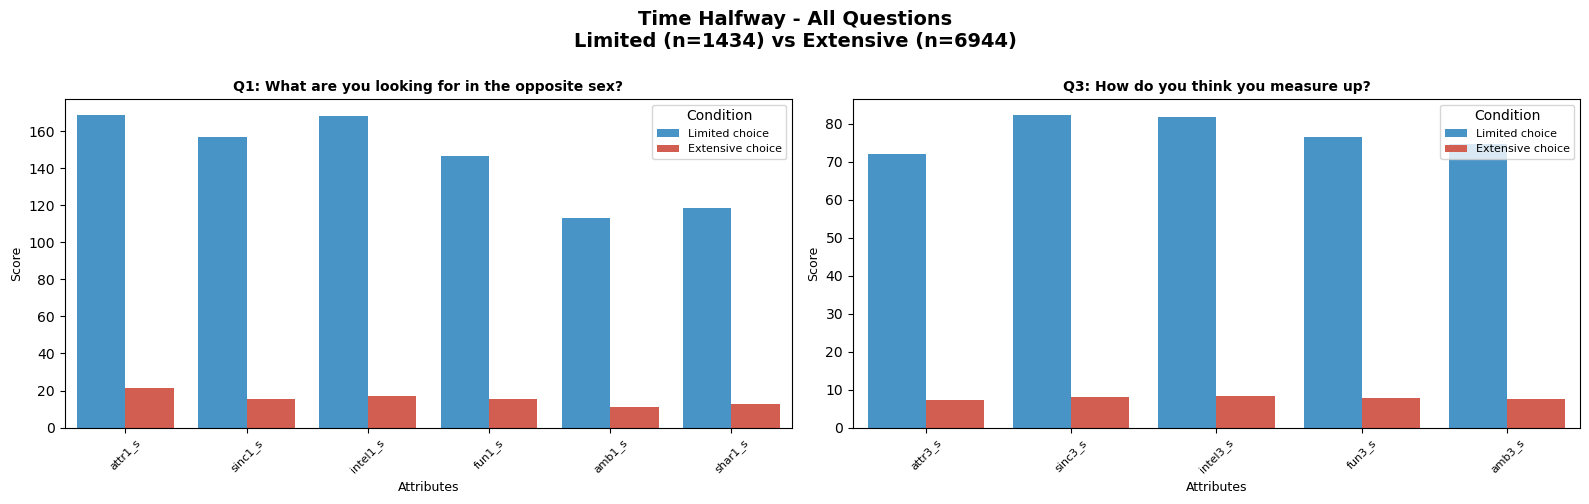

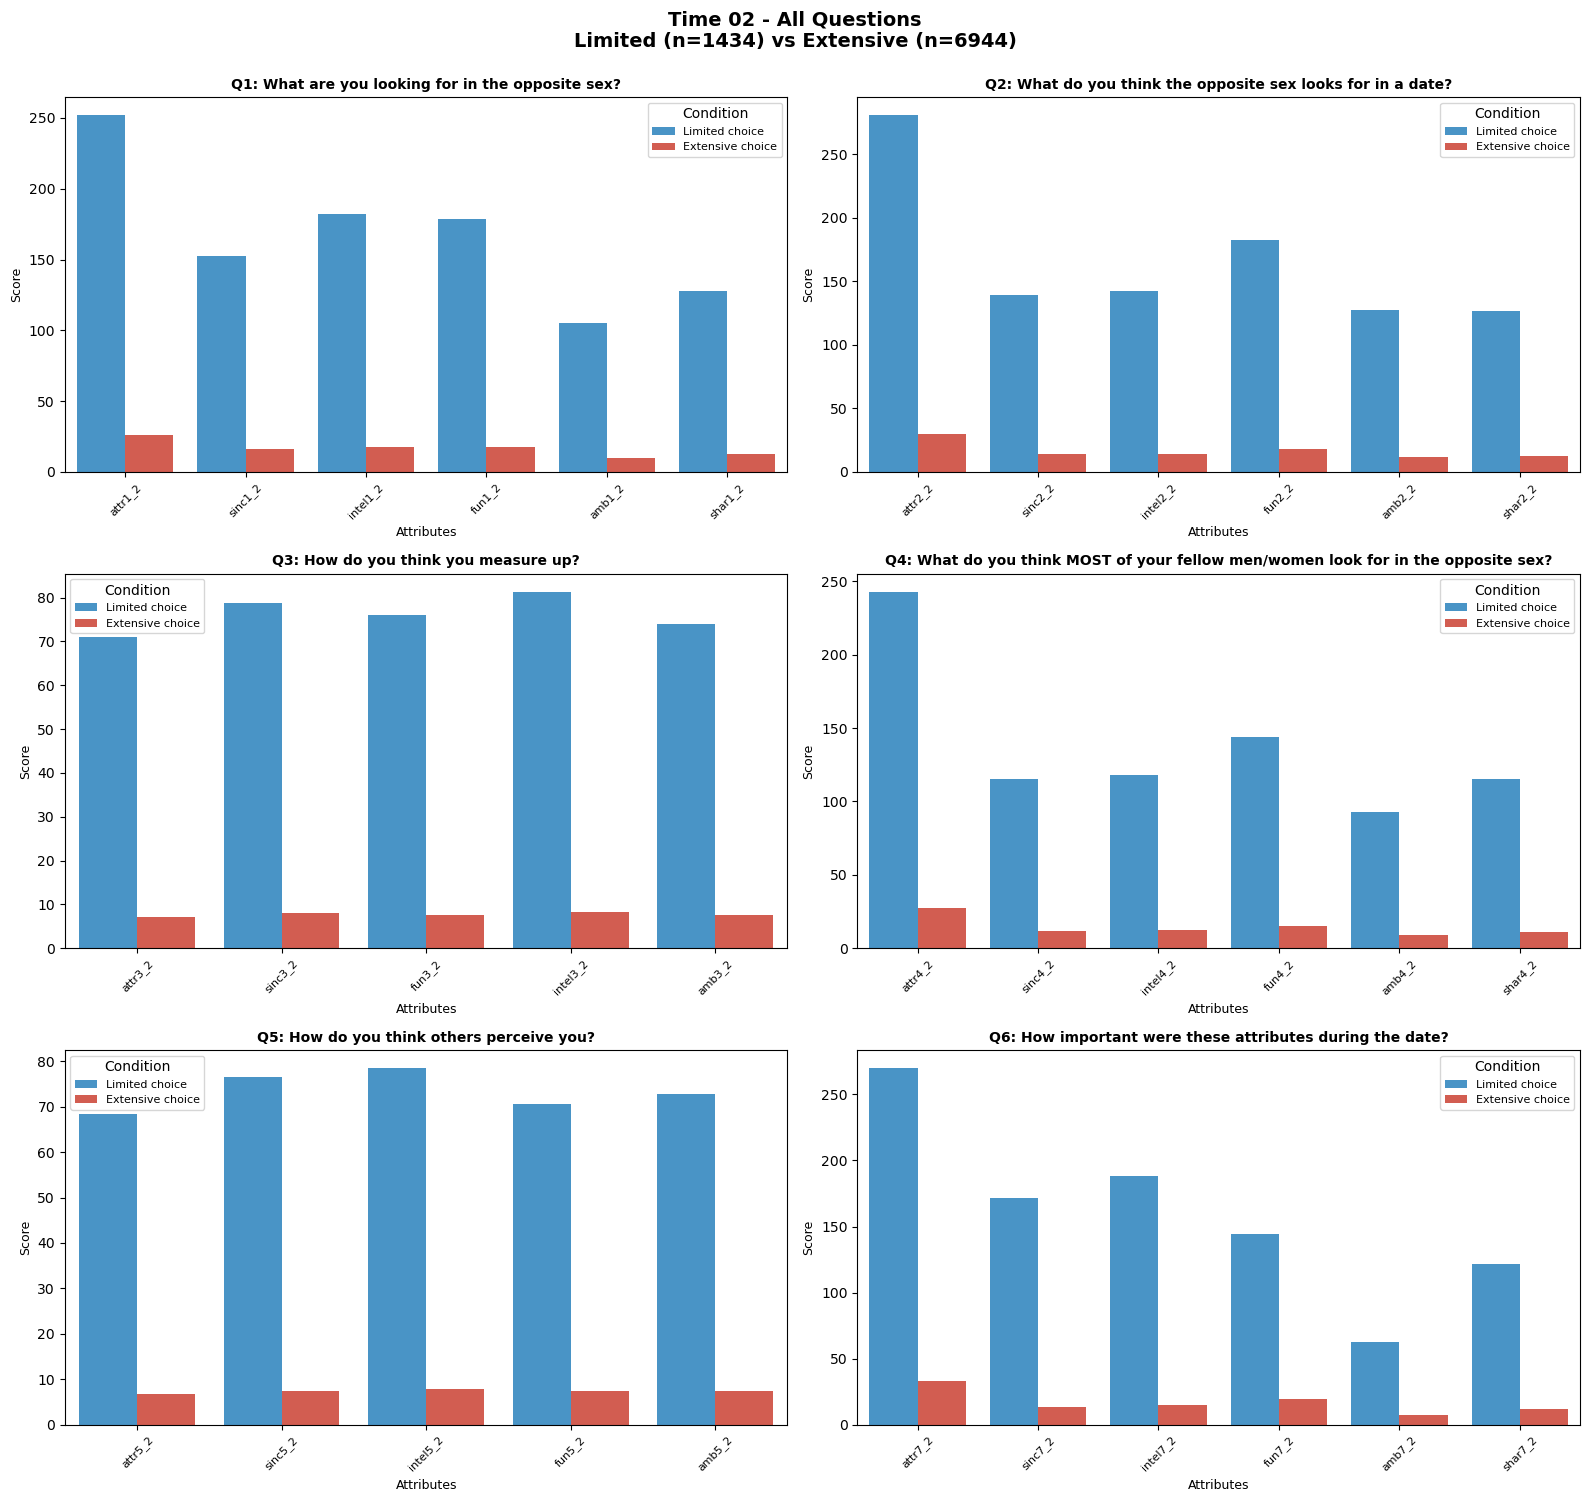

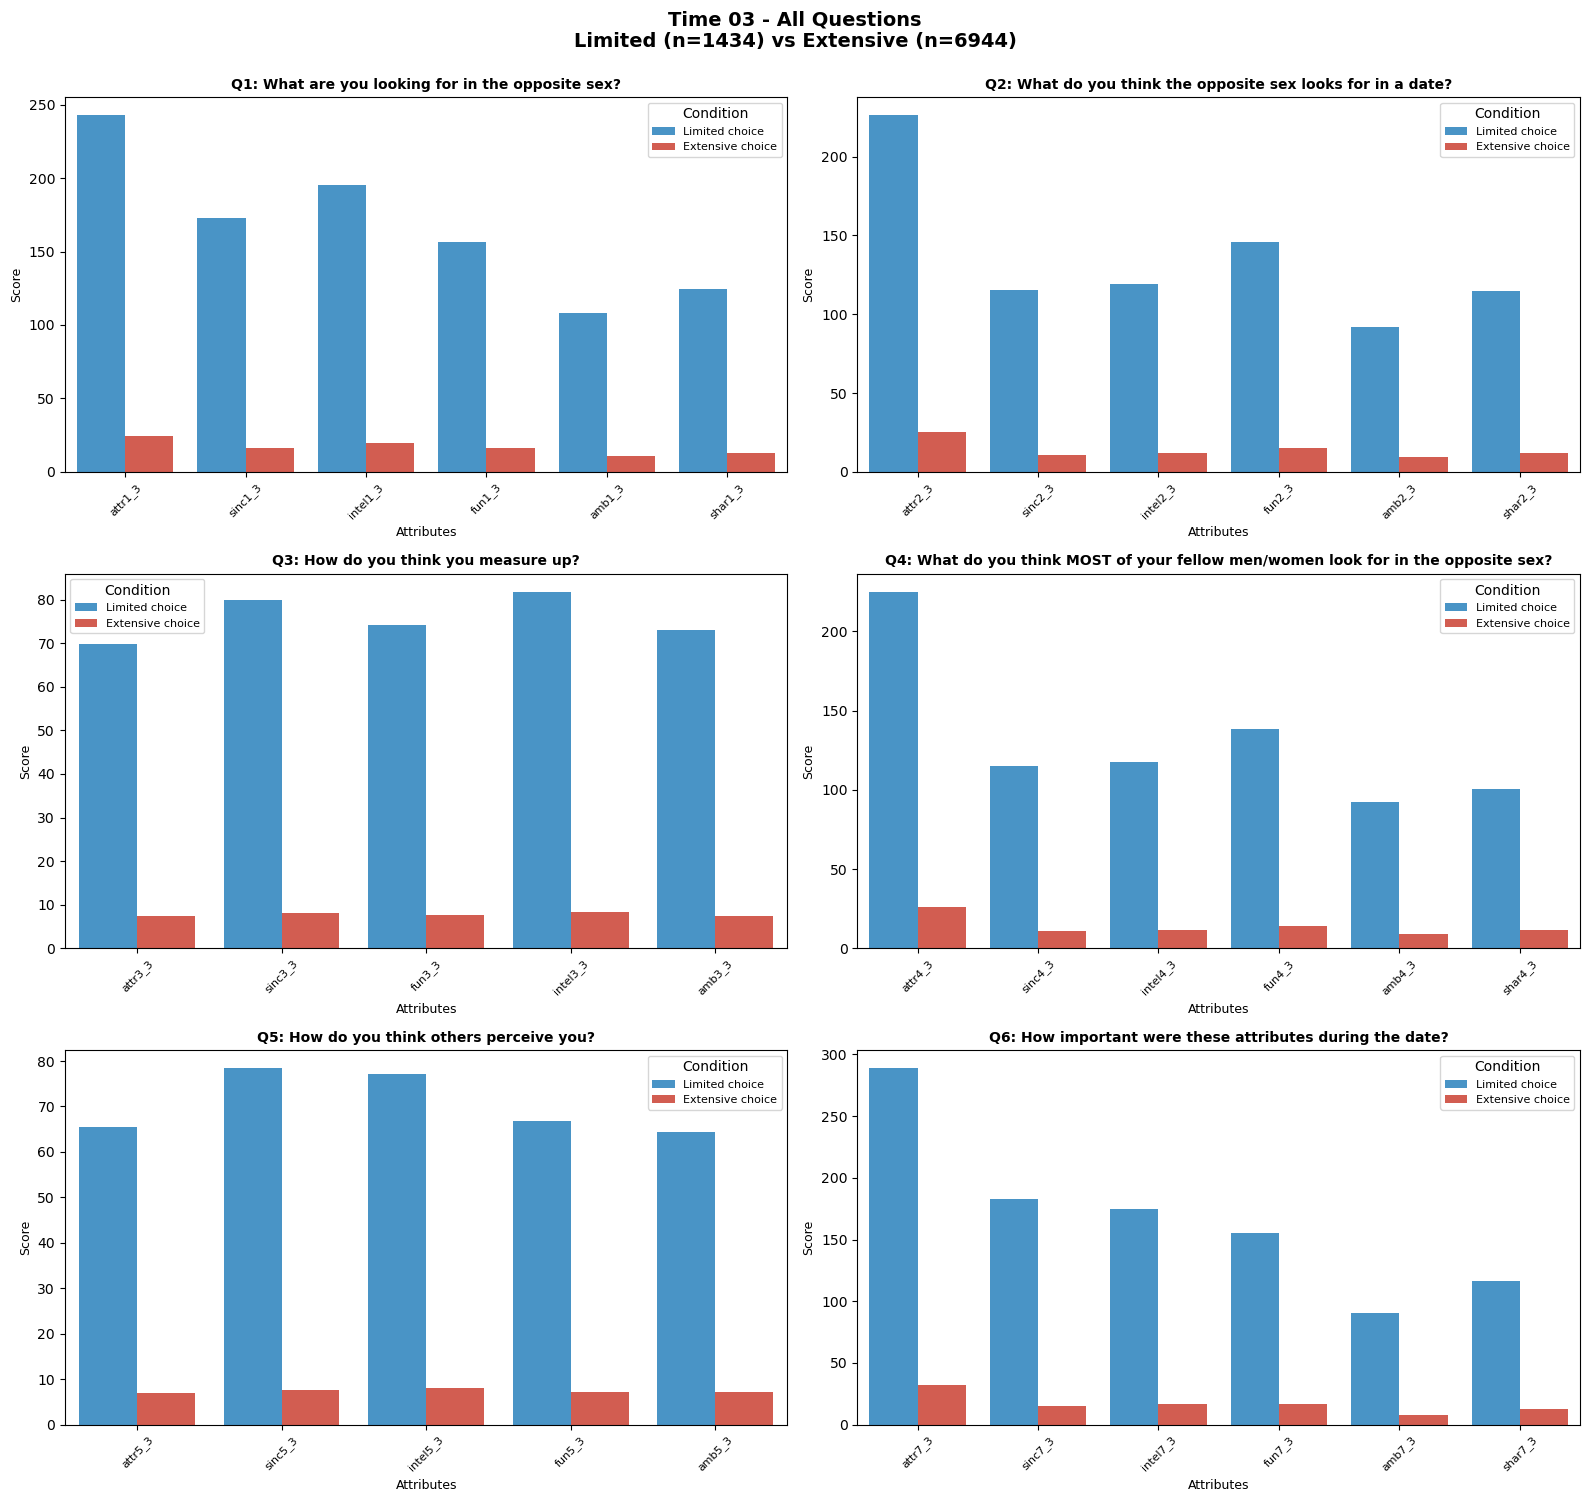

The differences between the two groups are not very marked.  
It can be observed that when people have complete freedom to allocate their points,
they tend to give more importance to physical attraction. However, in both groups, 
this criterion is present in the same proportion compared to the others. 
The differences between waves 6 to 9 and the others are therefore not really significant.
---
We therefore have a clear path to normalize the data for waves 6 to 9.


In [30]:
# --- Verification of a significant difference between 6 to 9 and the others  --- 
# verification between scorecards 
scorecard_limited_choice = df.loc[limited_choice, scorecard].mean()
scorecard_extensive_choice = df.loc[extensive_choice, scorecard].mean()
comparison_choice_wave = pd.DataFrame({
    '6 to 9 waves' : scorecard_limited_choice,
    'other waves' : scorecard_extensive_choice 
})

comparison_choice_wave.plot(kind='bar', figsize=(10, 6))
plt.title('Scorecard Comparison: Male vs Female')
plt.xlabel('Attributes')
plt.ylabel('Average Score')
plt.xticks(rotation=45)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

# varification between questionnaires  
def comparison_wave_time(time_dict, time_name):
    """Comparison of the two groups - all questions on one figure"""
    n_questions = len(time_dict)
    ncols = 2
    nrows = math.ceil(n_questions / ncols)
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 5 * nrows))
    
    # give attribute 'axis' for numpy.ndarray
    if n_questions == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    for idx, (question_id, variables) in enumerate(time_dict.items()):
        # calculate of average
        limited_mean = df.loc[limited_choice, variables].mean()
        extensive_mean = df.loc[extensive_choice, variables].mean()
        
        # DataFrame
        comparison_group = pd.DataFrame({
            'Limited choice': limited_mean,
            'Extensive choice': extensive_mean
        })
        
        # Seaborn
        comparison_long = comparison_group.reset_index().melt( id_vars='index',
        var_name='Condition', value_name='Score')
        comparison_long.rename(columns={'index': 'Attribute'}, inplace=True)
        sns.barplot(data=comparison_long, x='Attribute', y='Score', hue='Condition',
                    palette=['#3498db', '#e74c3c'], ax=axes[idx])
        axes[idx].set_title(f'{question_id.upper()}: {QUESTIONS[question_id]}',
            fontsize=10, fontweight='bold')
        axes[idx].set_xlabel('Attributes', fontsize=9)
        axes[idx].set_ylabel('Score', fontsize=9)
        axes[idx].tick_params(axis='x', rotation=45, labelsize=8)
        axes[idx].legend(title='Condition', fontsize=8)
    # hide empty charts 
    for idx in range(n_questions, len(axes)):
        axes[idx].set_visible(False) 
    # Title
    plt.suptitle(
        f'{time_name} - All Questions\n'
        f'Limited (n={limited_choice.sum()}) vs Extensive (n={extensive_choice.sum()})',
        fontsize=14,
        fontweight='bold',
        y=0.998
    )
    plt.tight_layout()
    plt.show()
# Graph creation
comparison_wave_time(time_01, 'Time 01')
comparison_wave_time(time_halfway, 'Time Halfway')
comparison_wave_time(time_02, 'Time 02')
comparison_wave_time(time_03, 'Time 03')
print("""The differences between the two groups are not very marked.  
It can be observed that when people have complete freedom to allocate their points,
they tend to give more importance to physical attraction. However, in both groups, 
this criterion is present in the same proportion compared to the others. 
The differences between waves 6 to 9 and the others are therefore not really significant.""")
print('---')
print('We therefore have a clear path to normalize the data for waves 6 to 9.')

In [ ]:
# --- Normalization of wave 6 to 9 --- 
# Addition of all questionnaires 
questionnaire_columns = []
for questionnaire in ALL_RESPONSES.values():
    for question_vars in questionnaire.values():
        questionnaire_columns.extend(question_vars)

# grouping with scorecards
columns_to_normalize = (
    scorecard +
    scorecard_partner +
    preferences_partner + 
    questionnaire_columns
)

# normalization 
for columns in columns_to_normalize:
    df.loc[limited_choice, columns] = df.loc[limited_choice, columns] * 10 

# Questions : 

- Are the qualities sought in a partner influenced by gender, social status, and age? 
- Are matches influenced by what the other person is looking for, their expectations, dating habits, age, social status, and gender? 
- Do people who have matched have similar careers, goals, habits, and expectations?
- Do the activities sought truly have an impact on matches? 
- What trends emerge from the different question sessions?

In [24]:
'''Is what we look for in a partner
influenced by gender, social status, and age?'''   
# genre 
scorecard_male = df.loc[male, scorecard].mean()
scorecard_female = df.loc[female, scorecard].mean()
comparison_gender = pd.DataFrame({
    'Male' : scorecard_male,
    'Female' : scorecard_female
})
display(comparaison_gender)


comparison_gender.plot(kind='bar', figsize=(10, 6))
plt.title('Scorecard Comparison: Male vs Female')
plt.xlabel('Attributes')
plt.ylabel('Average Score')
plt.xticks(rotation=45)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

print('The difference between the genders is minimal. Both genders generally looking for the same thing.')


NameError: name 'comparaison_gender' is not defined